In [1]:
import pandas as pd
from scipy.stats import pearsonr
import numpy as np
from scipy.stats import zscore
import random
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon

### Figure 2C¶

In [2]:
#### Importing delta (post-tretement-pre treatment) for each cytokine from TCGA bulk vs sc pseudobulk based model
#df_delta=pd.read_csv("/data/kumarr17/figures_to_upload/supplementray_table/compare_cyt_induced_delta_tcga_bulk_pseudobulk.csv",index_col='Unnamed: 0')
df_delta=pd.read_csv("/data/kumarr17/TxCyto/results/compare_cyt_induced_delta_tcga_bulk_pseudobulk.csv",index_col='Unnamed: 0')

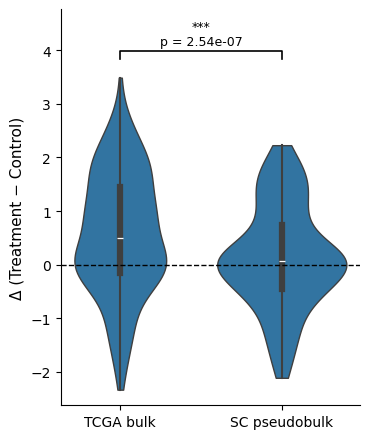

In [3]:

# ============================================================
# 1. Select paired observations
# ============================================================

plot_df = df_delta[
    [
        "TCGA_bulk_delta",
        "sc_pseudo_bulk_delta"
    ]
].dropna()


# ============================================================
# 2. Paired one-sided Wilcoxon test
# H1: TCGA_bulk_delta > sc_pseudo_bulk_delta
# ============================================================

stat, pval = wilcoxon(
    plot_df["TCGA_bulk_delta"],
    plot_df["sc_pseudo_bulk_delta"],
    alternative="greater"
)


# ============================================================
# 3. Convert to long format
# ============================================================

plot_df_long = plot_df.melt(
    var_name="Model",
    value_name="Delta"
)

plot_df_long["Model"] = plot_df_long["Model"].replace({
    "TCGA_bulk_delta": "TCGA bulk",
    "sc_pseudo_bulk_delta": "SC pseudobulk"
})


# ============================================================
# 4. figure
# ============================================================

fig, ax = plt.subplots(figsize=(3.8, 4.5))

sns.violinplot(
    data=plot_df_long,
    x="Model",
    y="Delta",
    inner="box",
    cut=0,
    linewidth=1,
    ax=ax
)


# ============================================================
# 5. Reference line at zero
# ============================================================

ax.axhline(
    y=0,
    color="black",
    linestyle="--",
    linewidth=1
)


# ============================================================
# 6. Significance bracket
# ============================================================

y_min = plot_df_long["Delta"].min()
y_max = plot_df_long["Delta"].max()
y_range = y_max - y_min

if y_range == 0:
    y_range = 1

bracket_y = y_max + 0.06 * y_range
bracket_height = 0.025 * y_range

ax.plot(
    [0, 0, 1, 1],
    [
        bracket_y,
        bracket_y + bracket_height,
        bracket_y + bracket_height,
        bracket_y
    ],
    color="black",
    linewidth=1.2
)


# ============================================================
# 7. Significance annotation
# ============================================================

if pval < 0.001:
    significance = "***"
elif pval < 0.01:
    significance = "**"
elif pval < 0.05:
    significance = "*"
else:
    significance = "ns"

ax.text(
    0.5,
    bracket_y + bracket_height + 0.01 * y_range,
    f"{significance}\np = {pval:.2e}",
    ha="center",
    va="bottom",
    fontsize=9
)


# ============================================================
# 8. Axis formatting
# ============================================================

ax.set_ylabel(
    "Δ (Treatment − Control)",
    fontsize=11
)

ax.set_xlabel("")

ax.tick_params(
    axis="x",
    labelsize=10
)

ax.tick_params(
    axis="y",
    labelsize=10
)

ax.set_ylim(
    y_min - 0.05 * y_range,
    y_max + 0.22 * y_range
)


# ============================================================
# 9. formatting
# ============================================================

sns.despine(ax=ax)

ax.grid(False)

plt.tight_layout()


# ============================================================
# 10. Save as vector SVG
# ============================================================

#fig.savefig(
#     "/data/kumarr17/figures_to_upload/Figure2/TCGA_bulk_vs_SC_pseudobulk_delta.svg",
#     format="svg",
#     bbox_inches="tight",
#     pad_inches=0.05
# )

plt.show()

### Plot Figure 2D

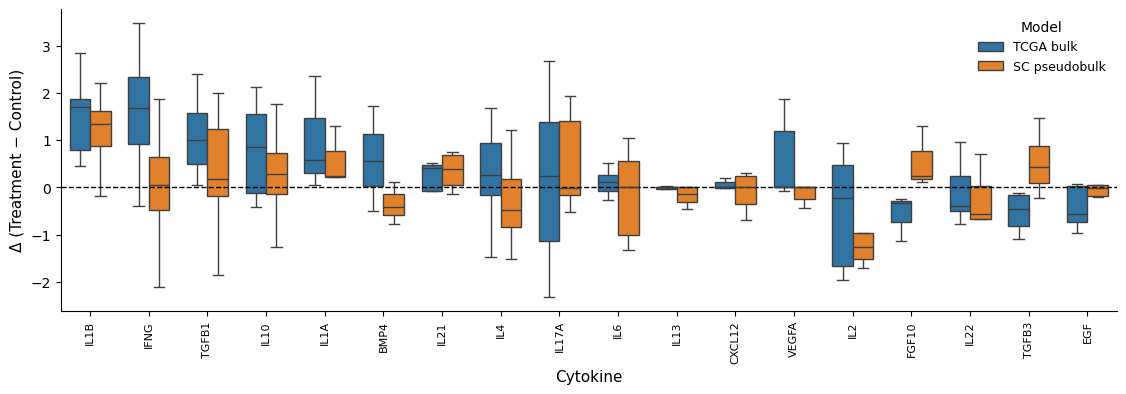

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 1. Prepare dataframe
# ============================================================

df_plot = df_delta.copy()

cols = [
    "TCGA_bulk_delta",
    "sc_pseudo_bulk_delta"
]


# ============================================================
# 2. Keep cytokines with at least 3 unique cohorts
# ============================================================

valid_cytokines = (
    df_plot
    .groupby("cytokine")["GSE"]
    .nunique()
)

valid_cytokines = valid_cytokines[
    valid_cytokines >= 3
].index

df_plot = df_plot[
    df_plot["cytokine"].isin(valid_cytokines)
].copy()


# ============================================================
# 3. Order cytokines by median TCGA-bulk delta
#    descending: highest -> lowest
# ============================================================

cytokine_order = (
    df_plot
    .groupby("cytokine")["TCGA_bulk_delta"]
    .median()
    .sort_values(ascending=False)
    .index
)


# ============================================================
# 4. Convert to long format
# ============================================================

df_long = df_plot.melt(
    id_vars=["GSE", "cytokine"],
    value_vars=cols,
    var_name="Model",
    value_name="Delta"
)

df_long["Model"] = df_long["Model"].replace({
    "TCGA_bulk_delta": "TCGA bulk",
    "sc_pseudo_bulk_delta": "SC pseudobulk"
})


# ============================================================
# 5. Create manuscript figure
# ============================================================

fig, ax = plt.subplots(figsize=(12, 4.5))

sns.boxplot(
    data=df_long,
    x="cytokine",
    y="Delta",
    hue="Model",
    order=cytokine_order,
    showfliers=False,
    width=0.7,
    linewidth=1,
    ax=ax
)


# ============================================================
# 6. Zero reference line
# ============================================================

ax.axhline(
    y=0,
    linestyle="--",
    color="black",
    linewidth=1
)


# ============================================================
# 7. Axis formatting
# ============================================================

ax.set_xlabel(
    "Cytokine",
    fontsize=11
)

ax.set_ylabel(
    "Δ (Treatment − Control)",
    fontsize=11
)

ax.tick_params(
    axis="x",
    labelrotation=90,
    labelsize=8
)

ax.tick_params(
    axis="y",
    labelsize=10
)


# ============================================================
# 8. Legend
# ============================================================

ax.legend(
    title="Model",
    frameon=False,
    fontsize=9,
    title_fontsize=10
)


# ============================================================
# 9.formatting
# ============================================================

sns.despine(ax=ax)

ax.grid(False)

fig.subplots_adjust(
    left=0.10,
    right=0.98,
    bottom=0.30,
    top=0.97
)


# ============================================================
# 10. Save as vector SVG
# ============================================================

#fig.savefig(
#     "/data/kumarr17/figures_to_upload/Figure2/TCGA_bulk_vs_SC_pseudobulk_delta_by_cytokine.svg",
#     format="svg",
#     bbox_inches="tight",
#     pad_inches=0.05
# )

plt.show()